## TASK4

In [33]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [34]:
data = load_wine()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [35]:
X = df.drop("target", axis=1)

y = df["target"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [38]:
predictions = model.predict(X_test)

In [39]:
accuracy_score(y_test, predictions)

1.0

In [40]:
joblib.dump(
    model,
    "wine_quality_model.pkl"
)

['wine_quality_model.pkl']

In [41]:
loaded_model = joblib.load(
    "wine_quality_model.pkl"
)

In [42]:
sample = X.iloc[0:1]

sample

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065.0


In [43]:
prediction = loaded_model.predict(sample)

prediction

array([0])

In [44]:
data.target_names[prediction]

array(['class_0'], dtype='<U7')

In [45]:
new_sample = pd.DataFrame(
    [X.iloc[10]],
    columns=X.columns
)

new_sample

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
10,14.1,2.16,2.3,18.0,105.0,2.95,3.32,0.22,2.38,5.75,1.25,3.17,1510.0


In [46]:
loaded_model.predict(new_sample)

array([0])

In [47]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
9,color_intensity,0.192639
6,flavanoids,0.165265
12,proline,0.146538
11,od280/od315_of_diluted_wines,0.140390
0,alcohol,0.105492
10,hue,0.065160
3,alcalinity_of_ash,0.045705
5,total_phenols,0.036698
4,magnesium,0.027099
1,malic_acid,0.026627


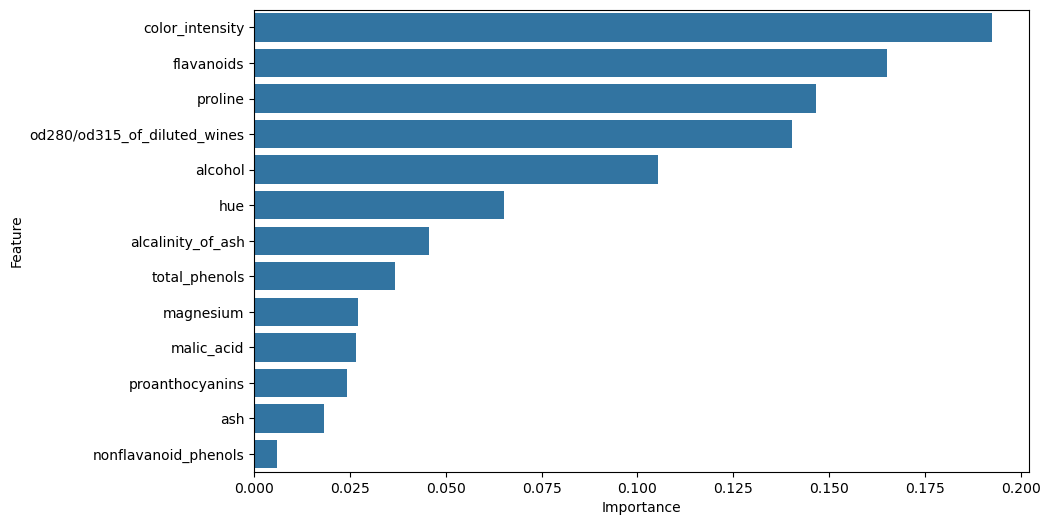

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=feature_importance["Importance"],
    y=feature_importance["Feature"]
)

plt.show()